# S&P 500 Financial Analysis

End-to-end analysis of S&P 500 constituents including 
data cleaning, exploratory analysis, and SQL window functions.

**Dataset:** 503 companies · 14 original columns · 2017 snapshot  
**Tools:** Python · pandas · NumPy · matplotlib · seaborn · SQLite

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

## 1. Loading & First Look

In [2]:
url = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies-financials/master/data/constituents-financials.csv"

df = pd.read_csv(url)
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.describe())
print(df.nlargest(5, 'Price/Earnings')[['Symbol','Name','Sector','Price/Earnings']])
print(df.nsmallest(5, 'Price/Earnings')[['Symbol','Name','Sector','Price/Earnings']])
print(df[df['Price/Earnings'] < 0][['Symbol','Name','Sector','Price/Earnings']])

(503, 14)
  Symbol                 Name                          Sector   Price  \
0    MMM                   3M        Industrial Conglomerates  152.90   
1    AOS          A. O. Smith               Building Products   56.76   
2    ABT  Abbott Laboratories           Health Care Equipment   86.97   
3   ABBV               AbbVie                   Biotechnology  215.40   
4    ACN            Accenture  IT Consulting & Other Services  186.22   

   Price/Earnings  Dividend Yield  Earnings/Share  52 Week Low  52 Week High  \
0       29.517374          0.0204            5.18       139.34        177.41   
1       15.136000          0.0255            3.75        54.16         81.87   
2       24.361345          0.0290            3.57        81.97        139.06   
3      105.588234          0.0325            2.04       181.73        244.81   
4       15.251433          0.0350           12.21       155.82        321.77   

     Market Cap        EBITDA  Price/Sales  Price/Book  \
0  7.974763e

## 2. Data Cleaning

Three issues identified during reconnaissance:
- 15 companies missing all financial metrics (systematic missingness)
- 102 missing Dividend Yield values — filled with 0 (companies that don't pay dividends)
- Price/Earnings outliers above 100 — flagged, not removed (economic outliers, not errors)
- SEC Filings column contains URLs with no analytical value — dropped

In [3]:
df = (
    df
    .assign(
        data_quality = lambda x: np.where(x['Price'].isnull(), 'incomplete', 'ok'),
        pe_outlier   = lambda x: x['Price/Earnings'] > 100,
    )
    .fillna({'Dividend Yield': 0})
    .drop(columns=['SEC Filings'])
)
assert df.shape == (503, 15), f"Unexpected shape: {df.shape}"
assert df['Dividend Yield'].isnull().sum() == 0, "Dividend Yield still has nulls"
assert df['data_quality'].value_counts().get('incomplete', 0) == 15, "Expected 15 incomplete records"
assert df['pe_outlier'].value_counts().get(True, 0) == 18, "Expected 15 P/E outliers"
print(df.shape) 

(503, 15)


## 3. Exploratory Analysis

**Finding 1:** S&P 500 representation is highly concentrated — 
a few sub-industries like Health Care Equipment dominate with 18 companies 
while most sub-industries have only one company large enough to qualify by market cap.

**Finding 2:** Health Care REITs trade at a median P/E of 77 vs Cable & Satellite 
at 4.3 — reflecting divergent investor expectations. The market prices in strong 
earnings growth for Real Estate while Cable & Satellite faces structural decline 
from streaming substitution.

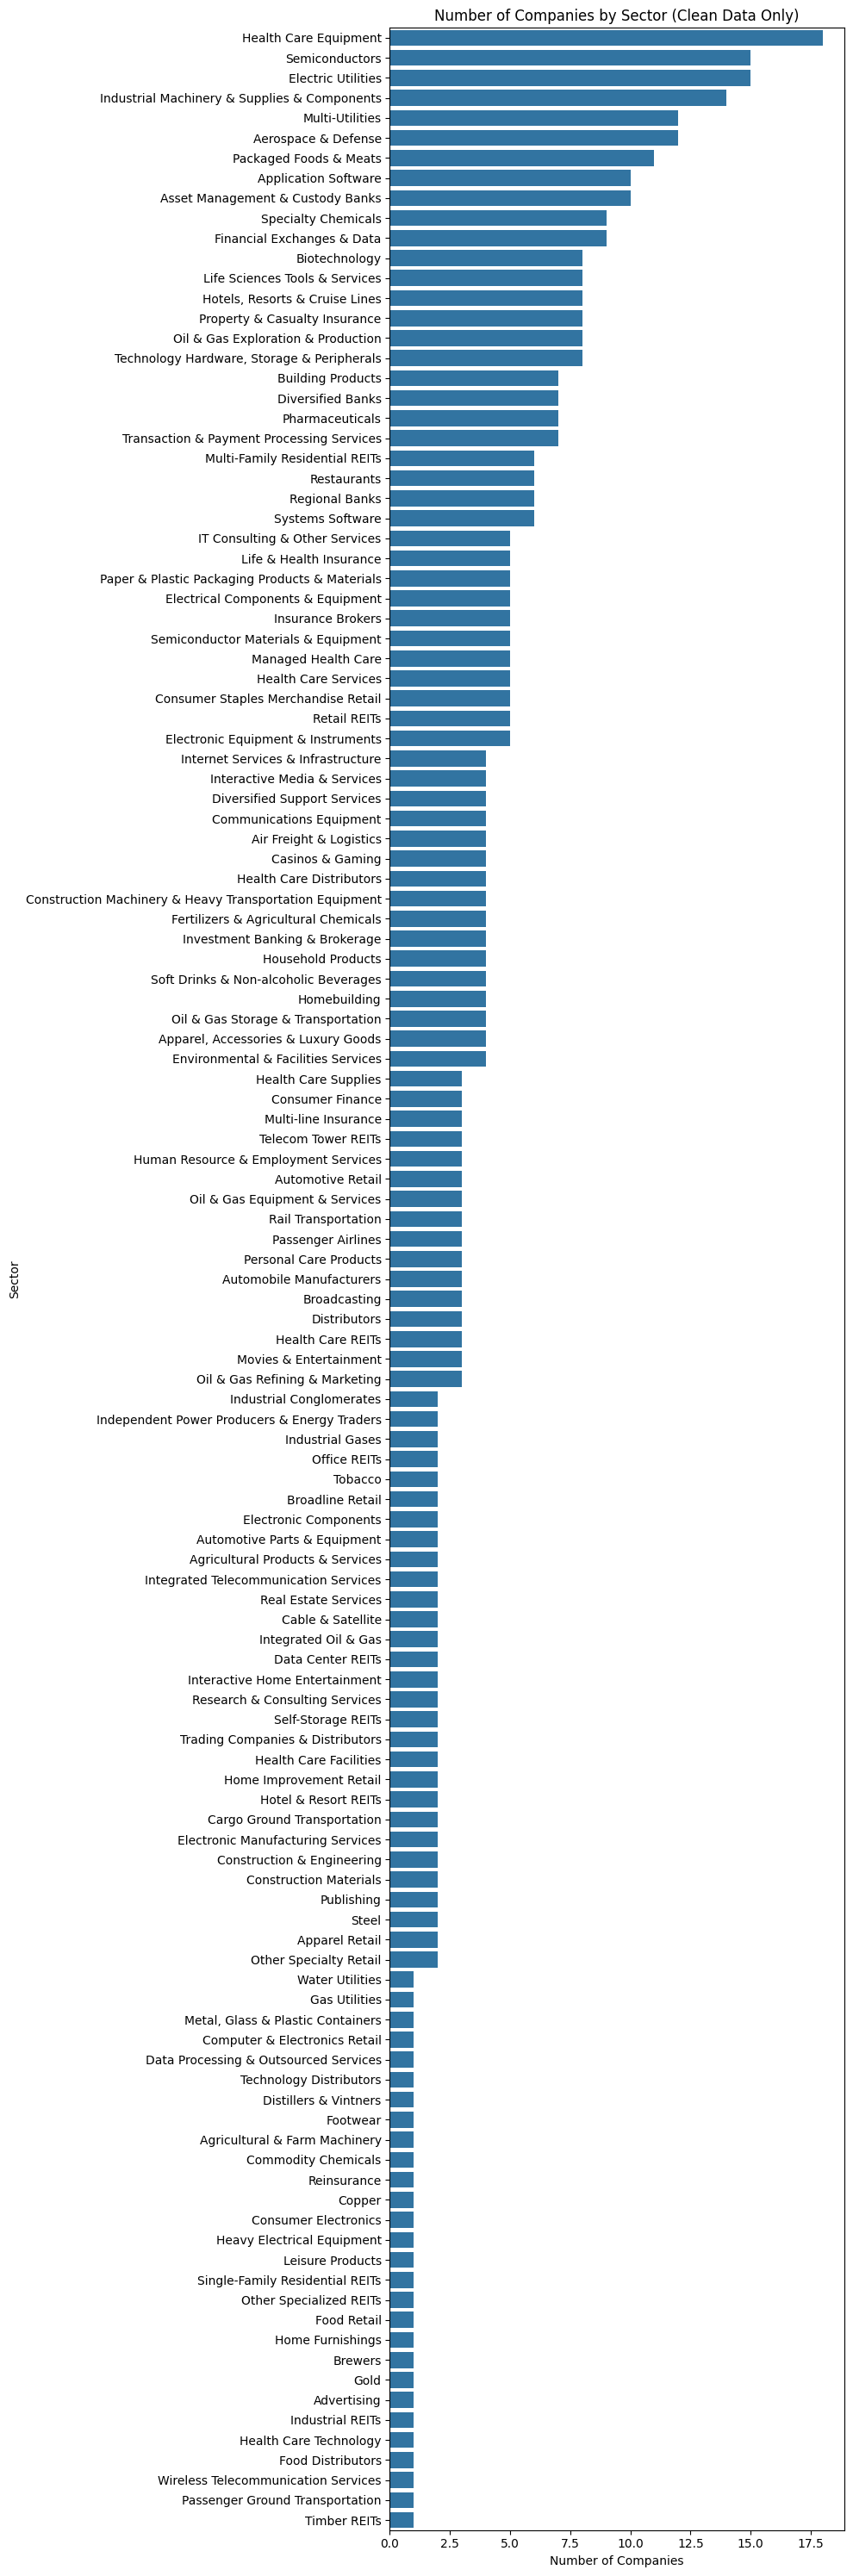

In [4]:
clean_df = df[df['data_quality'] == 'ok'].copy()
sector_counts = clean_df['Sector'].value_counts()

plt.figure(figsize=(10, 30))
sns.barplot(data=sector_counts.reset_index(), x='count', y='Sector')
plt.title('Number of Companies by Sector (Clean Data Only)')
plt.xlabel('Number of Companies')
plt.ylabel('Sector')
plt.tight_layout()
plt.show()

In [5]:
median_pe = (
    clean_df[~clean_df['pe_outlier']]
    .groupby('Sector')['Price/Earnings']
    .median()
    .reset_index()
    .rename(columns={'Price/Earnings': 'median_PE'})
    .sort_values('median_PE', ascending=False)
)
print(median_pe)

                                  Sector  median_PE
52                     Health Care REITs  77.576622
38                 Electronic Components  69.433820
23            Construction & Engineering  66.545085
108  Semiconductor Materials & Equipment  63.335224
30                     Data Center REITs  61.936843
..                                   ...        ...
17                     Cable & Satellite   4.333867
0                            Advertising        NaN
13                               Brewers        NaN
20                   Commodity Chemicals        NaN
77                      Leisure Products        NaN

[124 rows x 2 columns]


## 4. SQL Analysis

*Coming next session — 10 window function queries on sp500.db*